# Validation Pipeline Sketch V1

## 0. Imports and Set-Up:

In [ ]:
import multiprocessing
# import sys
# import logging

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from typing import Type, Any, Optional
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score, f1_score, confusion_matrix, silhouette_score, pairwise_distances
from sklearn.utils import check_random_state
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from matplotlib.ticker import MultipleLocator
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
import umap
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment
from scipy.stats import multivariate_normal
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from tqdm_joblib import tqdm_joblib
from tqdm.auto import tqdm
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
RANDOM_SEED = 1453
np.random.seed(RANDOM_SEED)

### 0.1 Data Import:

In [3]:
data_dir = Path('./data/DARMANIS')
data_fp = data_dir / 'GBM_raw_gene_counts.csv'
labels_fp = data_dir / 'GBM_metadata.csv'

In [4]:
# import pandas as pd

# # 1) Define a regex that matches a single space only if it's not inside quotes:
# sep_regex = r'\s(?=(?:[^"]*"[^"]*")*[^"]*$)'

# # 2) Read with the Python engine (so it honors regex sep + quotechar)
# meta = pd.read_csv(
#     labels_fp,
#     sep=sep_regex,
#     engine="python",
#     quotechar='"',
#     skipinitialspace=True  # drop any spurious space after splitting
# )

# # 3) Clean up column names (strip any remaining quotes)
# meta.columns = [col.strip('"') for col in meta.columns]

# # 4) (Optional) Convert obvious numeric columns
# numeric = [
#     "Total_reads","Unique_reads","Unique_reads_percent",
#     "Splice_sites_total","Splice_sites_Annotated","Splice_sites_GT.AG",
#     "Splice_sites_GC.AG","Splice_sites_AT.AC","Splice_sites_non_canonical",
#     "Multimapping_reads_percent","Unmapped_mismatch","Unmapped_short",
#     "Unmapped_other","ERCC_reads","Non_ERCC_reads","ERCC_to_non_ERCC",
#     "Genes_detected","Cluster_2d"
# ]
# for c in numeric:
#     if c in meta:
#         meta[c] = pd.to_numeric(meta[c], errors="coerce")
# meta.index = meta.index.str.replace(r'^"|"$', '', regex=True)
# print(meta.head())

In [5]:
# # regex: split on a space only if it’s not inside "...“
# sep_regex = r'\s(?=(?:[^"]*"[^"]*")*[^"]*$)'

# df = pd.read_csv(
#     data_fp,
#     sep=sep_regex,
#     engine="python",
#     quotechar='"',
#     header=0,
#     skipinitialspace=True
# )

# # strip any remaining quotes from the column names
# df.columns = [c.strip('"') for c in df.columns]
# df = df.T
# print(df.shape)
# print(df.columns[:5])
# print(df.head())

In [6]:

# adata = ad.AnnData(
#     X=df.values,
#     obs=meta.loc[df.index],
#     var=pd.DataFrame(index=df.columns)
# )
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
# adata.write_h5ad("data/darmanis_fromraw.h5ad")
# adata

In [7]:
# tsne_df = pd.read_csv("GBM_TSNE", index_col=0)  
# # or however you have them in memory:
# # tsne_df = pd.DataFrame(tsne_og, index=adata.obs_names, columns=['TSNE1','TSNE2'])

# # --- 3) add to adata.obsm ---
# adata.obsm['X_tsne_og'] = tsne_df.loc[adata.obs_names].values

# # --- 4) (optional) save ---
# adata.write_h5ad("data/darmanis_with_tsne_og.h5ad")

# # Now you can plot it in Scanpy:
# sc.pl.embedding(
#     adata, 
#     basis='tsne_og', 
#     color=['Location','Selection'], 
#     title=['Original t-SNE by Location','Original t-SNE by Selection']
# )

### 0.2 Importing raw data

In [8]:
adata = ad.read_h5ad('data/darmanis_fromraw.h5ad')

#read in their original tSNE coordinates
tsne_df = pd.read_csv(
    "/Users/tarekzikry/Documents/GitHub/ClusteringValidation/data/DARMANIS/GBM_TSNE.csv",
    sep=r"\s+",           # regex for any whitespace
    engine="python",      # needed when sep is a regex
    header=None,          # don’t try to interpret the first row as names
    names=["cell","Dim1","Dim2"],
    skiprows=1,           # drop that wonky header line
    index_col=0
)
tsne_df.index = tsne_df.index.str.replace('"', '', regex=False)

# 2) ensure the index is string-typed (usually not strictly necessary, but safe)
tsne_df.index = tsne_df.index.astype(str)
# 3) merge into your AnnData by index:
common = adata.obs_names.intersection(tsne_df.index)
adata = adata[common].copy()
adata.obsm['X_tsne_og'] = tsne_df.loc[common, ['Dim1','Dim2']].values


### 1.1 Select 500 highly variable genes while accounting for batch effects

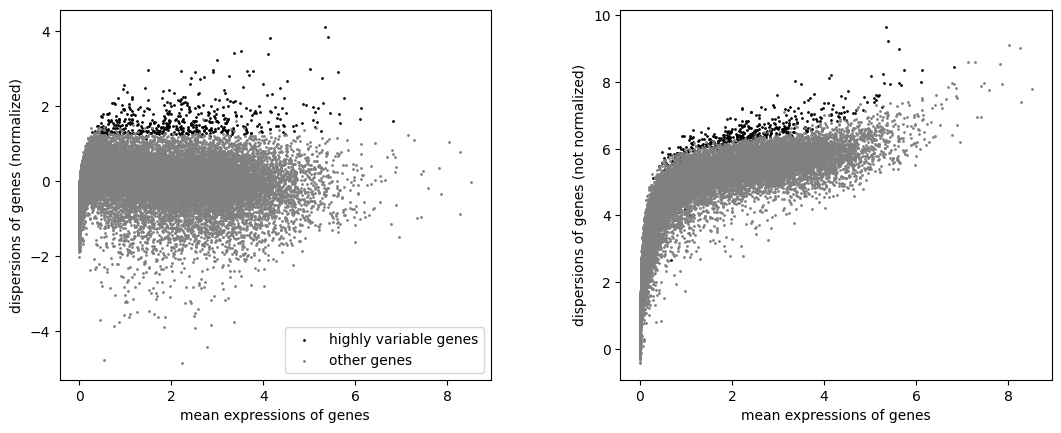

In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat')
sc.pl.highly_variable_genes(adata)

#### Now follow the clustering steps from the original Darmanis et. al 2017 paper. This entails:
1. Select 500 highly variable genes based on over-dispersion (above).  
2. Compute the cell–cell Euclidean distance matrix.  
3. Run t-SNE on the distance matrix.  
4. Cluster the cells into 12 groups using k-means clustering.  

"In brief, we selected genes with the highest over-dispersion (n = 500) and used them to construct a cell-to-cell dissimilarity matrix. We then performed t-distributed stochastic neighbor embedding (tSNE) on the resulting distance matrix to create a 2D map of all cells. Finally, we used k-means clustering on the 2D tSNE map, resulting in the identification of 12 distinct cell types within separate clusters (Figure 2A)."

In [10]:
# 1) Select just the highly variable genes
adata_hvg = adata[:, adata.var['highly_variable']]
X = adata_hvg.X
# 2) Create cell-cell distance matrix
dist_matrix = squareform(pdist(X, metric='euclidean'))
# 3) Run tSNE on the distance matrix
tsne = TSNE(
    n_components=2,
    metric='precomputed',
    perplexity=50,
    init='random',
    random_state=RANDOM_SEED
)
coords = tsne.fit_transform(dist_matrix)

# 4) Run KMeans with k=12 on the same coords
kmeans = KMeans(n_clusters=12, random_state=RANDOM_SEED).fit(coords)
cluster_labels = kmeans.labels_.astype(str)
unique_clusters = np.unique(cluster_labels)
cmap20     = plt.get_cmap('tab20')
clust_colors = {cl: cmap20(i) for i, cl in enumerate(unique_clusters)}

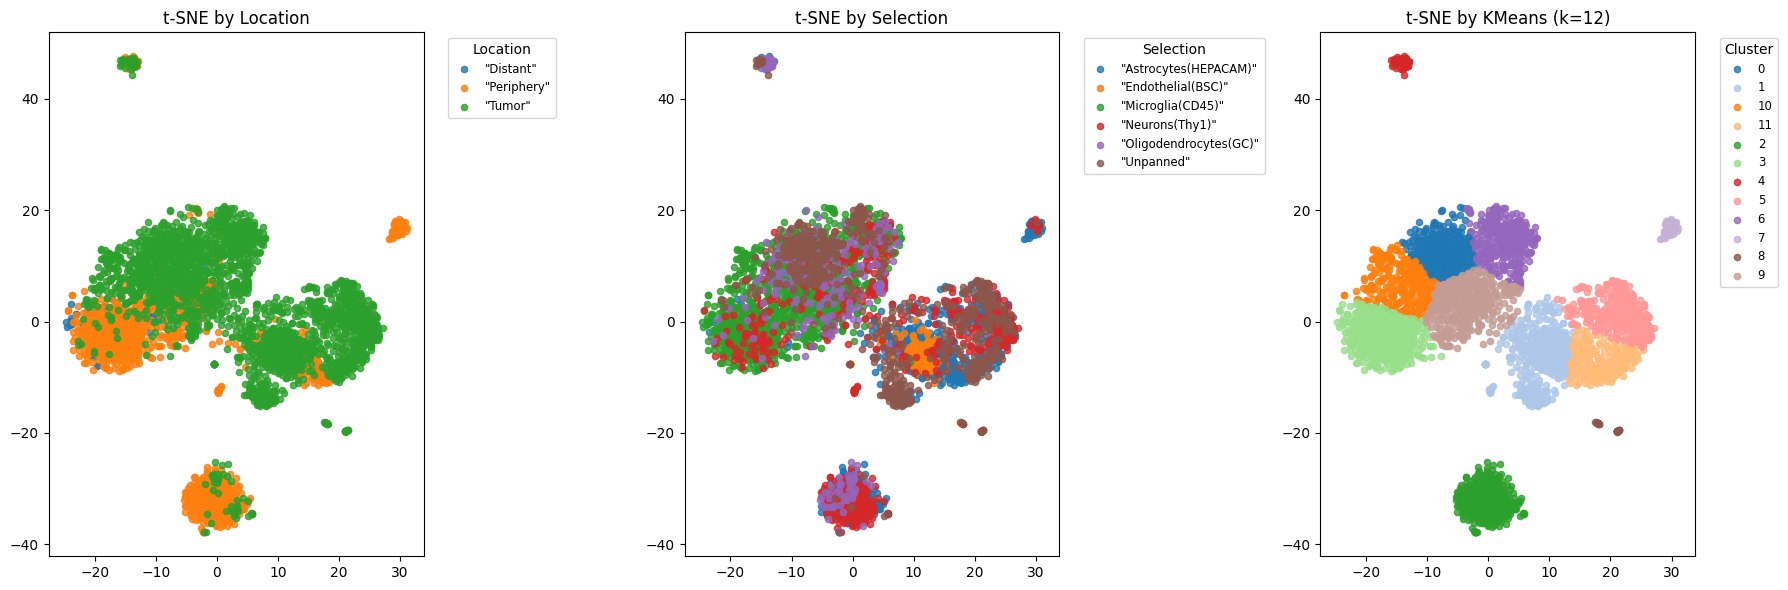

In [11]:
# Let's visualize the tSNE across the location of the cells and the cell types
locations  = adata_hvg.obs['Location'].astype(str).values
selections = adata_hvg.obs['Selection'].astype(str).values

unique_locs = np.unique(locations)
unique_sels = np.unique(selections)
cmap10      = plt.get_cmap('tab10')
loc_colors  = {loc: cmap10(i) for i, loc in enumerate(unique_locs)}
sel_colors  = {sel: cmap10(i) for i, sel in enumerate(unique_sels)}


#Plot 1×3 panel
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# — Left: by Location
ax = axes[0]
for loc in unique_locs:
    mask = (locations == loc)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[loc_colors[loc]], label=loc, s=20, alpha=0.8)
ax.set_title('t-SNE by Location')
ax.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# — Middle: by cell type
ax = axes[1]
for sel in unique_sels:
    mask = (selections == sel)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[sel_colors[sel]], label=sel, s=20, alpha=0.8)
ax.set_title('t-SNE by Selection')
ax.legend(title='Selection', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# — Right: by KMeans clusters
ax = axes[2]
for cl in unique_clusters:
    mask = (cluster_labels == cl)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[clust_colors[cl]], label=cl, s=20, alpha=0.8)
ax.set_title('t-SNE by KMeans (k=12)')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.show()

#### No information was given on the 12 clusters were chosen in the paper. Maybe they used commonly used metrics such as Silhouette score, or the Gap statistic to pick their number of clusters. Let's try them out. If they did, then the highest values, or at least the elbows on the plots, should be seen as k = 12.

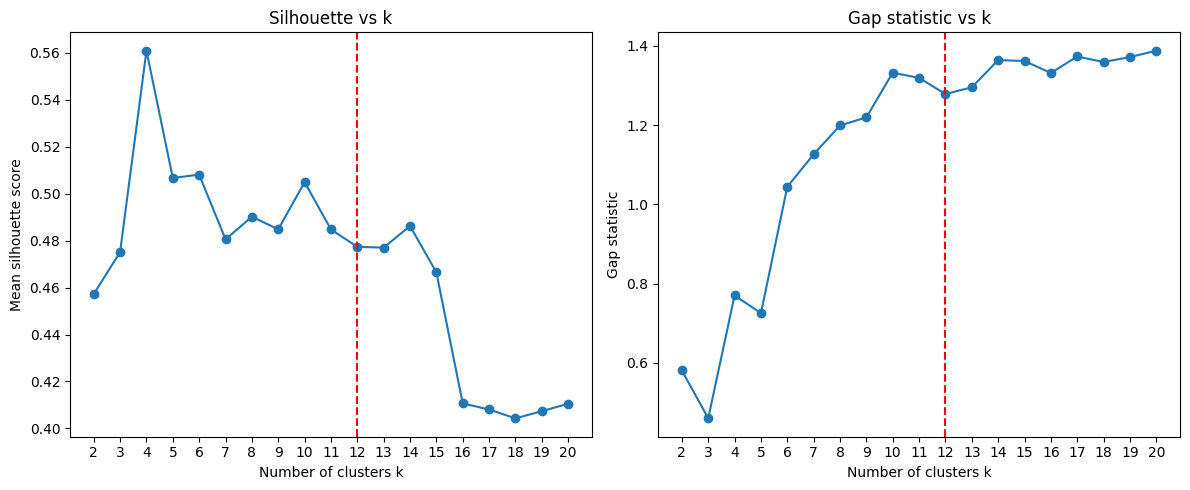

In [12]:
# Scan over 2 to 20 clusters
ks = range(2, 21)
B  = 20
sil_scores = []
gap_stats   = []

# precompute bounding box of your t-SNE map
mins = coords.min(axis=0)
maxs = coords.max(axis=0)

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED).fit(coords)
    labels = km.labels_
    sil_scores.append(silhouette_score(coords, labels))

    Wk = np.sum((coords - km.cluster_centers_[labels])**2)
    Wk_refs = []
    for _ in range(B):
        ref = np.random.uniform(mins, maxs, size=coords.shape)
        km_ref = KMeans(n_clusters=k, random_state=RANDOM_SEED).fit(ref)
        Wk_refs.append(np.sum((ref - km_ref.cluster_centers_[km_ref.labels_])**2))

    log_Wk    = np.log(Wk)
    log_Wkref = np.log(Wk_refs)
    gap_stats.append(log_Wkref.mean() - log_Wk)

# ---- plot side by side ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

# Silhouette plot
ax = axes[0]
ax.plot(list(ks), sil_scores, marker='o')
ax.axvline(12, color='red', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Mean silhouette score')
ax.set_title('Silhouette vs k')

# Gap statistic plot
ax = axes[1]
ax.plot(list(ks), gap_stats, marker='o', linestyle='-')
ax.axvline(12, color='red', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Gap statistic')
ax.set_title('Gap statistic vs k')

plt.show()

#### So we can see that neither of these metrics would lead us to choose 12 clusters. We tried our best to recapitulate their clustering pipeline given the details in the paper, but what if we had made different choices (different numbers of highly variable genes, or not accounting for batch effects)? How would our clustering have changed?

#### Here we try different choices of HVG numbers and accounting for batch effects vs. not. Other choices could include the method of selecting HVGs, seed when running tSNE or KMeans, etc.

In [ ]:
X_tsne = coords
# Define all clustering algorithms (k=12)
clusterers = {
    'kmeans':        KMeans(n_clusters=12, random_state=RANDOM_SEED),
    'spectral_50':   SpectralClustering(
                         n_clusters=12,
                         affinity='nearest_neighbors',
                         n_neighbors=50,
                         random_state=RANDOM_SEED
                     ),
    'spectral_100':   SpectralClustering(
                         n_clusters=12,
                         affinity='nearest_neighbors',
                         n_neighbors=100,
                         random_state=RANDOM_SEED
                     ),
    'spectral_150':   SpectralClustering(
                         n_clusters=12,
                         affinity='nearest_neighbors',
                         n_neighbors=200,
                         random_state=RANDOM_SEED
                     ),
    'hier_ward':     AgglomerativeClustering(
                         n_clusters=12,
                         linkage='ward'
                     ),
    'hier_complete': AgglomerativeClustering(
                         n_clusters=12,
                         linkage='complete'
                     ),
}

# Fit each and collect labels
labels_dict = {}
for name, algo in clusterers.items():
    labels = algo.fit_predict(X_tsne)
    labels_dict[name] = labels

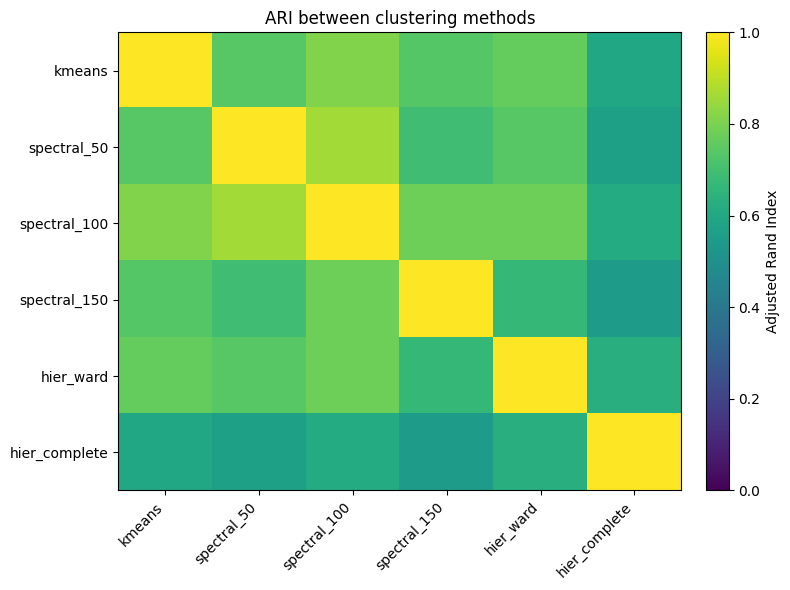

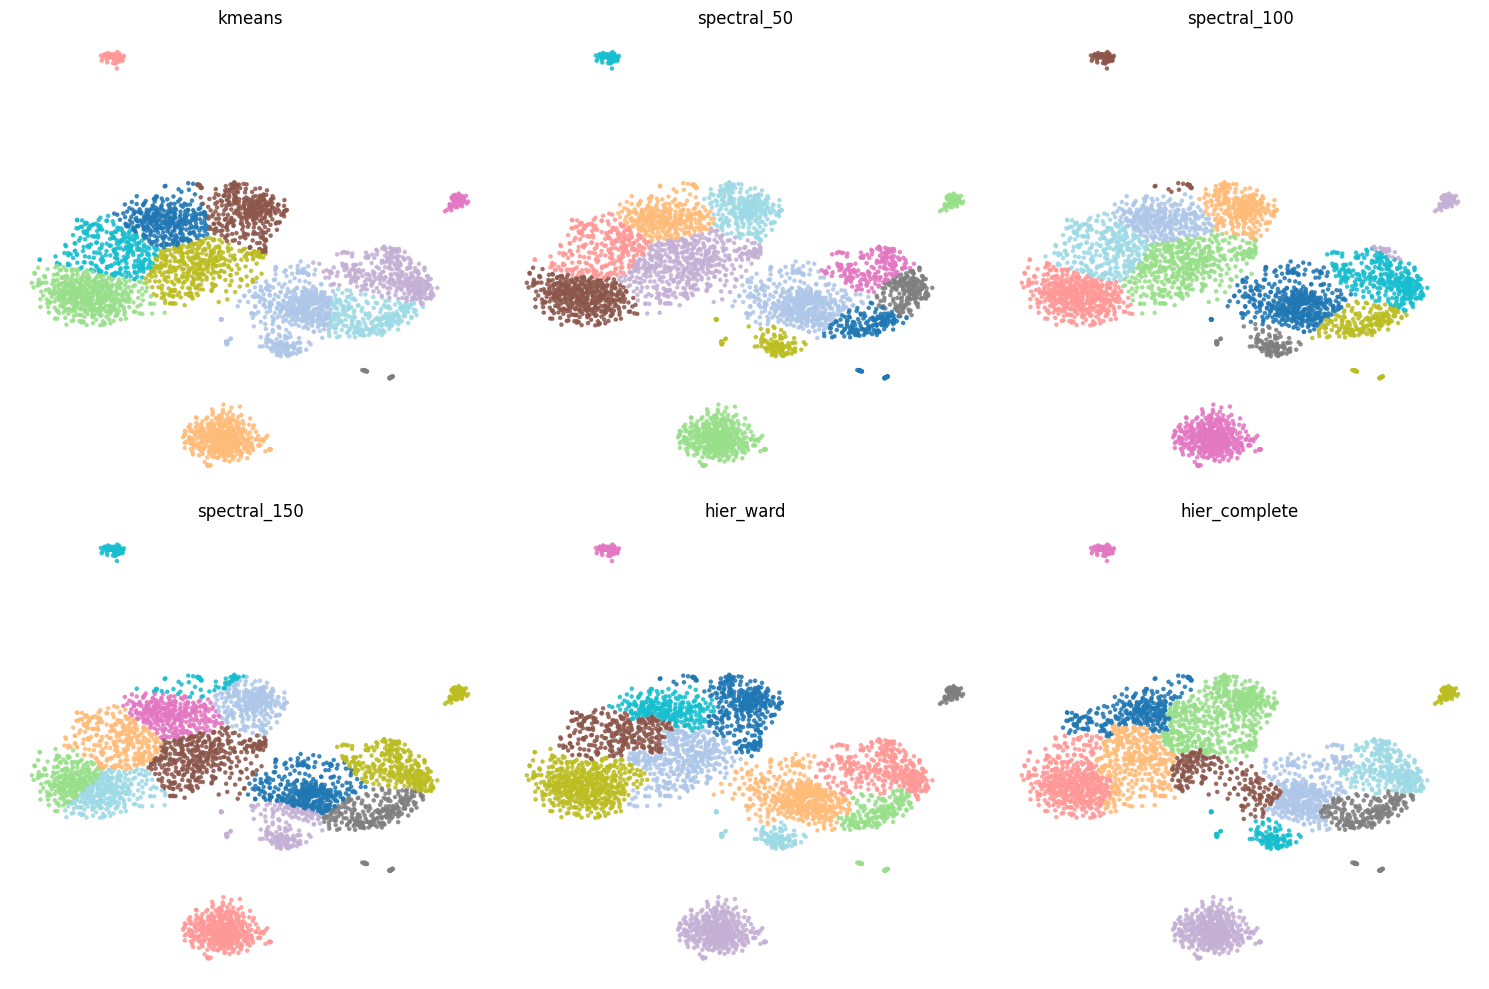

In [14]:
from itertools import combinations

# --- 1) ARI heatmap between methods ---
methods = list(labels_dict.keys())

# Build ARI matrix
ari_df = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m in methods:
    ari_df.loc[m, m] = 1.0
for m1, m2 in combinations(methods, 2):
    ari = adjusted_rand_score(labels_dict[m1], labels_dict[m2])
    ari_df.loc[m1, m2] = ari
    ari_df.loc[m2, m1] = ari

# Plot ARI heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ari_df.values, vmin=0, vmax=1, cmap='viridis', aspect='auto')
ax.set_xticks(np.arange(len(methods)))
ax.set_yticks(np.arange(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.set_yticklabels(methods)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Adjusted Rand Index')
ax.set_title('ARI between clustering methods')
plt.tight_layout()
plt.show()

# --- 2) t-SNE panel colored by each method ---
n_methods = len(methods)
n_cols = 3
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), tight_layout=True)
axes = axes.flatten()

cmap = plt.get_cmap('tab20')

for ax, method in zip(axes, methods):
    labels = labels_dict[method]
    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=labels, cmap=cmap,
        s=5, alpha=0.8
    )
    ax.set_title(method)
    ax.set_axis_off()

# hide any empty subplots
for ax in axes[n_methods:]:
    ax.set_visible(False)

plt.show()

#### As we can see above, the ARI between different clustering pipeline choices is pretty strong. This shows that the clustering pipeline described in the initial study is not very sensitive to differences in clustering method, if *k*=12 is chosen. However, based on the silhouette and gap statistic shown above, it is hard to determine if that is the right number of clusters. Based on the silhouette, what if we had chosen *k*=4?

```plaintext
Algorithm: Model Explorer - Ben-Hur et al., 2002

Input:
  X               # a dataset
  k_max           # maximum number of clusters
  num_subsamples  # number of subsamples

Output:
  S(i, k)         # similarities for each k and each pair of subsamples

Require:
  cluster(X, k)   # a clustering algorithm that returns labels
  s(L1, L2)       # a similarity measure between two label‐vectors

1.  f ← 0.8
2.  for k ← 2 to k_max do
3.      for i ← 1 to num_subsamples do
4.          sub1 ← subsamp(X, f)        ⟨a subsample of fraction f⟩
5.          sub2 ← subsamp(X, f)
6.          L1   ← cluster(sub1, k)
7.          L2   ← cluster(sub2, k)
8.          Intersect ← sub1 ∩ sub2
9.          S(i, k) ← s( L1[Intersect], L2[Intersect] )
            ⟨compute similarity on points common to both subsamples⟩
10.     end for
11. end for

Here, we use num_subsamples = 100, and L() as the adjusted rand index (ARI).

In [15]:
def cluster_stability(X, clusterer,
                      subsample_frac=0.8, n_runs=100):
    """
    Cluster stability index

    Computes the cluster stability index using the Jaccard similarity
    coefficient between two clusterings, obtained using two random 
    subsamples of the data. Implements the method described in
    Ben-Hur (2002).

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Data matrix
    clusterer : object
        Clustering estimator with fit_predict method
    subsample_frac : float, default=0.8
        Fraction of data to subsample
    n_runs : int, default=100
        Number of runs for cluster stability computation

    Returns
    -------
    stability : float
        Cluster stability index
    stability_dist : list
        List of cluster stability values for each run
    """
    X = pd.DataFrame(X)
    n_samples = X.shape[0]
    stability_dist = []
    for _ in range(n_runs):
        # get two subsamples of the data
        idx1 = np.random.choice(n_samples, int(subsample_frac*n_samples), replace=False)
        idx2 = np.random.choice(n_samples, int(subsample_frac*n_samples), replace=False)
        X1, X2 = X.iloc[idx1, :], X.iloc[idx2, :]
        
        # cluster using each subsample
        labels1 = clusterer.fit_predict(X1)
        labels2 = clusterer.fit_predict(X2)

        labels_mat = np.zeros((n_samples, 2))
        labels_mat[idx1, 0] = labels1
        labels_mat[idx2, 1] = labels2

        # compute jaccard similarity between clusterings
        joint_idx = np.intersect1d(idx1, idx2)
        stability_dist.append(adjusted_rand_score(labels_mat[joint_idx, 0], labels_mat[joint_idx, 1]))
    stability = np.mean(stability_dist)
    return stability, stability_dist


def jaccard_similarity(x, y):
    """
    Jaccard similarity coefficient between two cluster membership vectors

    Parameters
    ----------
    x : array-like, shape (n_samples,)
        Cluster membership vector
    y : array-like, shape (n_samples,)
        Cluster membership vector

    Returns
    -------
    jaccard : float
        Jaccard similarity coefficient
    """
    x = np.array(x)
    y = np.array(y)

    # nxn neighborhood matrix with 0s on diagonal
    C_x = np.equal.outer(x, x).astype(int)
    np.fill_diagonal(C_x, 0)
    C_y = np.equal.outer(y, y).astype(int)
    np.fill_diagonal(C_y, 0)
    
    # compute jaccard similarity
    N11 = np.sum(C_x * C_y)
    j = N11 / (np.sum(C_x) + np.sum(C_y) - N11)
    return j

In [16]:
X_tsne_train, X_tsne_test = train_test_split(
    X_tsne,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True
)

print(f"Train set:  {X_tsne_train.shape[0]} cells")
print(f"Test set:   {X_tsne_test.shape[0]} cells")

Train set:  2871 cells
Test set:   718 cells


#### Define all our clustering methods of interest.

In [31]:
# Define clusterer factories that take k and return a fresh estimator
clusterer_factories = {
    'kmeans': lambda k: KMeans(n_clusters=k, random_state=RANDOM_SEED),
    'spectral_50': lambda k: SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=50, 
        random_state=RANDOM_SEED
    ),
    'spectral_100': lambda k: SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=100, 
        random_state=RANDOM_SEED
    ),
    'spectral_150': lambda k: SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=150, 
        random_state=RANDOM_SEED
    ),
    'hier_ward': lambda k: AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    ),
    'hier_complete': lambda k: AgglomerativeClustering(
        n_clusters=k,
        linkage='complete'
    ),
}

#### Run stability analyses from Model Explorer for each clustering method from *k*=2 to 20. Here, I comment it out and preload the cached results to save time (takes about 2 hours).

In [ ]:
# import warnings
# warnings.filterwarnings("ignore")


# # Prepare results container
# ks = range(2, 21)
# stability_results = {name: {} for name in clusterer_factories}

# for k in tqdm(ks, desc="Evaluating stability for k"):
#         for name, factory in clusterer_factories.items():
#             clusterer = factory(k)
#             mean_stab, stab_dist = cluster_stability(
#                 X_tsne_train,
#                 clone(clusterer),
#                 subsample_frac=0.8,
#                 n_runs=100
#             )
#             stability_results[name][k] = {
#                 'mean_stability': mean_stab,
#                 'stability_dist': stab_dist
#             }

# # Extract mean stability into a DataFrame for plotting or analysis
# mean_df = pd.DataFrame({
#     name: {k: stability_results[name][k]['mean_stability'] for k in ks}
#     for name in clusterer_factories
# })
# mean_df.index.name = 'k'
# print(mean_df)

In [ ]:
# mean_df.to_csv('data/stability_df.csv')

In [ ]:
mean_df = pd.read_csv('data/stability_df.csv')
mean_df = mean_df.set_index('k')
mean_df

,kmeans,spectral_50,spectral_100,spectral_150,hier_ward,hier_complete
k,,,,,,
2,0.799304,0.311173,0.947460,1.000000,0.967424,0.867479
3,0.810242,0.535305,0.997261,0.997258,0.970042,0.869598
4,0.837268,0.693476,0.968387,0.979510,0.803927,0.902755
5,0.813778,0.754497,0.952141,0.969497,0.859504,0.874712
6,0.837451,0.774445,0.962466,0.962021,0.773871,0.699798
7,0.822547,0.697318,0.926090,0.967296,0.708730,0.622335
8,0.786541,0.742553,0.952134,0.972088,0.721842,0.618422
9,0.817161,0.731018,0.895423,0.971448,0.731416,0.628772
10,0.824364,0.779425,0.949667,0.939335,0.749270,0.598691


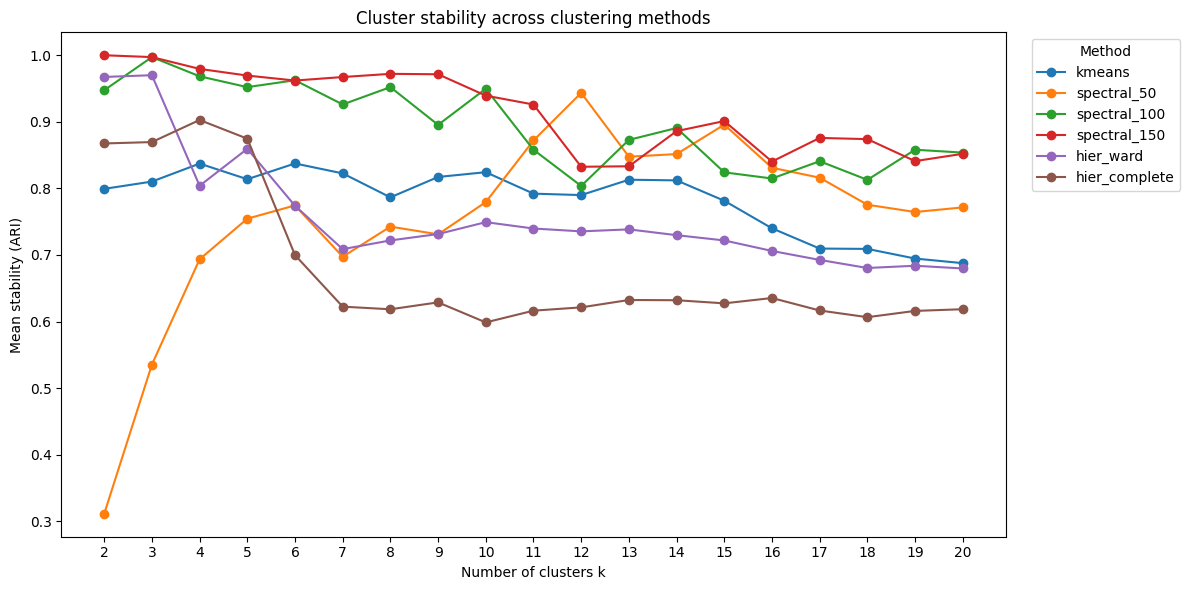

In [ ]:
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(12, 6))

for method in mean_df.columns:
    ax.plot(
        mean_df.index,
        mean_df[method],
        marker='o',
        label=method
    )

ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Mean stability (ARI)')
ax.set_title('Cluster stability across clustering methods')
ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_locator(MultipleLocator(1))  # integer ticks

plt.tight_layout()
plt.show()

### Generalizability

1. Cluster the training data: $y_{train} = Clusterer(X_{train})$  
2. Train a Random Forest classifier on the training set: $RF(X_{train}, y_{train})$  
3. Predict cluster labels for the test data: $\hat y_{test} = RF(X_{test})$  
4. Compute the adjusted Rand index: $ARI(\hat y_{test}, y_{test})$

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

def cluster_generalizability(
    X_train, 
    X_test, 
    clusterer, 
    rf_kwargs=None
):
    """
    Evaluate the generalizability of a clustering algorithm.

    Parameters
    ----------
    X_train : array-like, shape (n_train, n_features)
        Training data.
    X_test : array-like, shape (n_test, n_features)
        Test data.
    clusterer : estimator
        A clustering estimator with a fit_predict method.
    rf_kwargs : dict, optional
        Keyword arguments to pass to RandomForestClassifier.

    Returns
    -------
    ari : float
        Adjusted Rand Index between the true test clusters (from reclustering X_test)
        and the clusters predicted by the random forest trained on X_train.
    """
    # 1) Fit clustering on train and test separately
    y_train = clusterer.fit_predict(X_train)
    clusterer_test = clone(clusterer)
    y_test  = clusterer_test.fit_predict(X_test)

    # 2) Fit a random forest to predict train labels from X_train
    rf = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1, **(rf_kwargs or {}))
    rf.fit(X_train, y_train)

    # 3) Predict cluster labels on X_test
    y_pred = rf.predict(X_test)

    # 4) Compute ARI between true and predicted test labels
    ari = adjusted_rand_score(y_test, y_pred)
    return ari

In [ ]:
# Prepare results container
ks = range(2, 21)
gen_results = {name: {} for name in clusterer_factories}

for k in tqdm(ks, desc="Evaluating generalizability for k"):
        for name, factory in clusterer_factories.items():
            clusterer = factory(k)
            mean_gen = cluster_generalizability(
                X_train=X_tsne_train,
                X_test=X_tsne_test,
                clusterer=clone(clusterer)
            )
            gen_results[name][k] = {
                'mean_generalizabilty': mean_gen
            }

Evaluating generalizability for k:   0%|          | 0/19 [00:00<?, ?it/s]

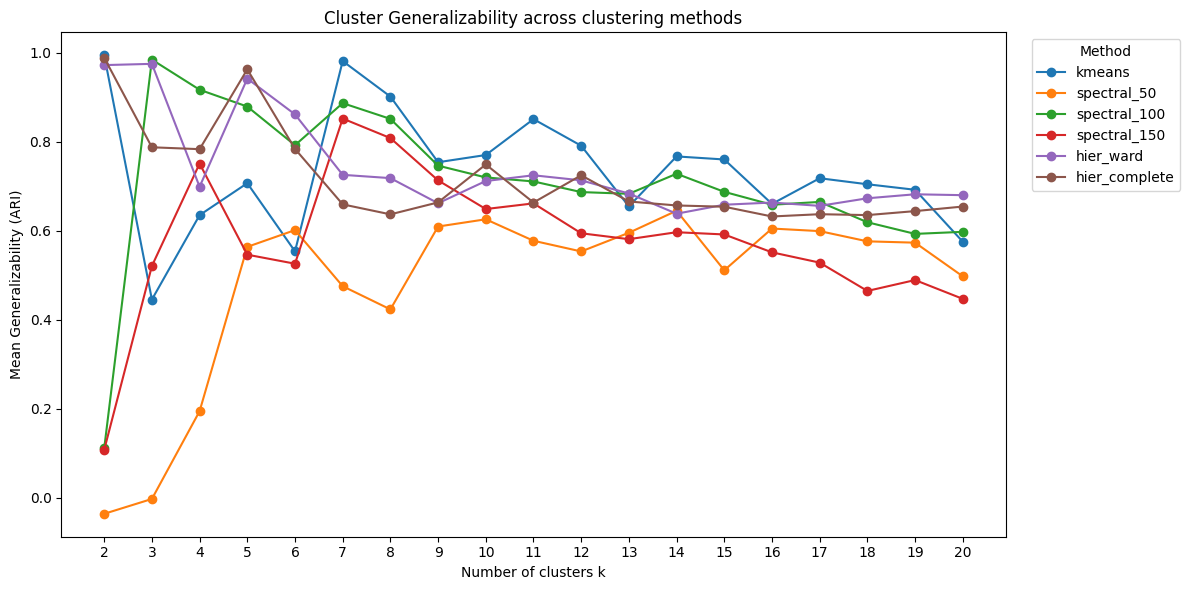

In [35]:
# Extract mean stability into a DataFrame for plotting or analysis
# mean_df = pd.DataFrame({
#     name: {k: gen_results[name][k]['mean_generalizabilty'] for k in ks}
#     for name in clusterer_factories
# })
# mean_df.index.name = 'k'


# Plot
k_vals = sorted(gen_results[next(iter(gen_results))].keys())

# 2) Build a DataFrame of mean stabilities for each method
df_gen = pd.DataFrame({
    method: [
        gen_results[method][k]['mean_generalizabilty'] 
        for k in k_vals
    ]
    for method in gen_results
}, index=k_vals)

# 3) Plot all lines on one axis
fig, ax = plt.subplots(figsize=(12, 6))
for method in df_gen.columns:
    ax.plot(df_gen.index, df_gen[method], marker='o', label=method)

# 4) Formatting
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Mean Generalizability (ARI)')
ax.set_title('Cluster Generalizability across clustering methods')
ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_locator(MultipleLocator(1))  # integer ticks

plt.tight_layout()
plt.show()

#### Based on these plots, *k*=7 seems promising. It has the highest generalizability, and also approximately the highest stability. Other values such as *k*=5 also seem promising and could warrant further investigation. To look at this further, we will carry out consensus clustering, with the six methods we have used above, and 7 clusters.

```plaintext
Algorithm: Consensus Clustering Across Methods

Input:
  X                  # data matrix of shape (n_samples, n_features)
  M                  # set of clustering methods {m₁, m₂, …, m_p}
  k                  # desired number of clusters

Output:
  consensus_matrix   # n×n matrix of co-clustering frequencies
  consensus_labels   # final cluster labels for each sample
  Z                  # hierarchical linkage on 1−consensus_matrix

Require:
  cluster(m, X, k)        # runs method m on X with k clusters, returns length-n labels
  hierarchical_linkage(D) # returns linkage matrix from distance matrix D
  cut_tree(Z, k)          # cuts linkage Z into k clusters

1.  labels_list ← empty list
2.  for each method m in M do
3.      L ← cluster(m, X, k)
4.      append L to labels_list
5.  end for
6.  n ← number of rows in X
7.  initialize consensus_matrix[n,n] ← 0
8.  for each L in labels_list do
9.      for i ← 1 to n do
10.         for j ← 1 to n do
11.             if L[i] == L[j] then
12.                 consensus_matrix[i,j] ← consensus_matrix[i,j] + 1
13.             end if
14.         end for
15.     end for
16. end for
17. consensus_matrix ← consensus_matrix / length(labels_list)
18. D ← 1 − consensus_matrix
19. Z ← hierarchical_linkage(D)
20. consensus_labels ← cut_tree(Z, k)
21. return consensus_matrix, consensus_labels, Z

In [47]:
def get_consensus_neighborhood_matrix(cluster_list):
    """
    Compute the NxN consensus neighborhood matrix where entry (i, j)
    is the fraction of labelings in which samples i and j share the same cluster.

    Parameters
    ----------
    cluster_list : list of array-like, each of shape (n_samples,)
        Each element is a vector of integer cluster labels for all n_samples.

    Returns
    -------
    nbhd_mat : ndarray, shape (n_samples, n_samples)
        nbhd_mat[i, j] = fraction of labelings in which i and j co-cluster.
    """
    # number of samples
    n = len(cluster_list[0])
    # accumulator for co-cluster counts
    sum_mat = np.zeros((n, n), dtype=float)
    # accumulator for total labelings (same shape; will be constant)
    count_mat = np.zeros((n, n), dtype=float)

    for labels in cluster_list:
        labels = np.asarray(labels)
        # boolean matrix: True where labels match
        eq = (labels[:, None] == labels[None, :])
        # add to sum and count
        sum_mat   += eq.astype(float)
        count_mat += 1.0

    # divide to get fraction
    nbhd_mat = sum_mat / count_mat
    return nbhd_mat

In [44]:
# Get 7-cluster labels from each method on the full t-SNE embedding
labels7 = {
    name: factory(7).fit_predict(X_tsne)
    for name, factory in clusterer_factories.items()
}

# Build a list of the label vectors
labels_list = list(labels7.values())

# Compute the consensus neighborhood matrix (no bootstrapping)
consensus_mat = get_consensus_neighborhood_matrix(labels_list)

# consensus_mat[i, j] is now the fraction of methods
# (out of your six) that placed cells i and j in the same cluster.
consensus_mat = get_consensus_neighborhood_matrix(labels_list)

#### Visualize the consensus matrix (sorted), then we can hierarchically cluster on the consensus matrix directly to get the 7 clusters we found to be optimal from stability and generalizability, and visualize these 7 clusters on the tSNE plot. 

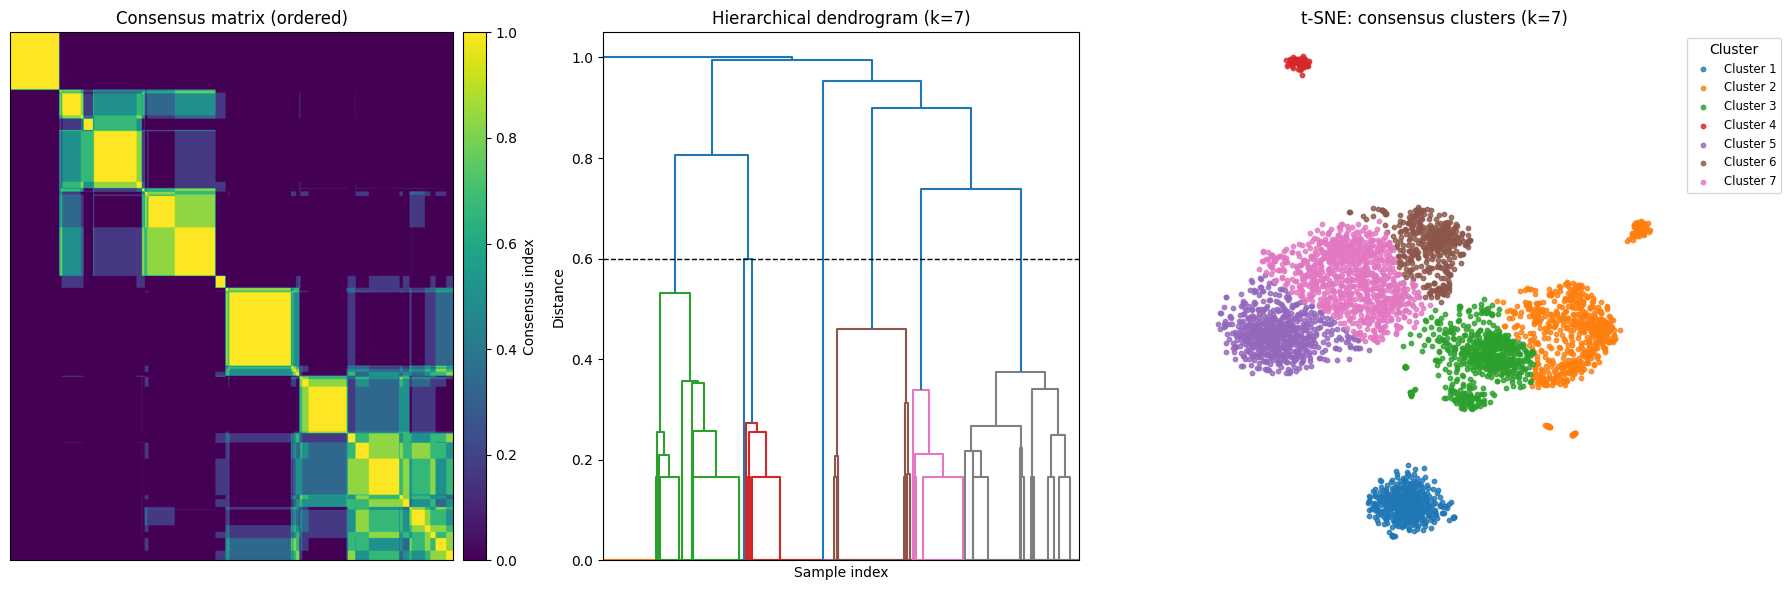

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# — Assume you have:
#    X_tsne        : (n_cells, 2) array of t-SNE coords on full data
#    consensus_mat : (n_cells, n_cells) matrix from get_consensus_neighborhood_matrix

# 1) Hierarchical clustering on 1 – consensus
dist       = 1.0 - consensus_mat
condensed  = squareform(dist, checks=False)
Z          = linkage(condensed, method='average')

# 2) Reorder samples by dendrogram leaves for the heatmap
leaves     = dendrogram(Z, no_plot=True)['leaves']
consensus_ord = consensus_mat[np.ix_(leaves, leaves)]

# 3) Cut into 7 consensus clusters
consensus_labels = fcluster(Z, t=7, criterion='maxclust')

# 4) Plot 1×3 panel
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# Panel 1: Ordered consensus heatmap
ax = axes[0]
im = ax.imshow(consensus_ord, vmin=0, vmax=1, cmap='viridis', aspect='auto')
ax.set_title('Consensus matrix (ordered)')
ax.set_xticks([]); ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Consensus index')

# Panel 2: Dendrogram
ax = axes[1]
dendrogram(Z, no_labels=True, color_threshold=Z[-7,2], ax=ax)
ax.axhline(Z[-7,2], color='k', linestyle='--', linewidth=1)
ax.set_title('Hierarchical dendrogram (k=7)')
ax.set_xlabel('Sample index')
ax.set_ylabel('Distance')

# Panel 3: t-SNE colored by consensus clusters
ax = axes[2]
cmap_disc = plt.get_cmap('tab10')
for i, cl in enumerate(np.unique(consensus_labels)):
    mask = (consensus_labels == cl)
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=10,
        alpha=0.8,
        color=cmap_disc(i),
        label=f'Cluster {cl}'
    )
ax.set_title('t-SNE: consensus clusters (k=7)')
ax.set_axis_off()
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

plt.show()

#### To look at sample-wise and cluster-wise variability, we can take the mean of each consensus clustering row as a measure of stability, and a mean of each cluster-wise block for group-wise measures, and then visualize them on the tSNE plot.

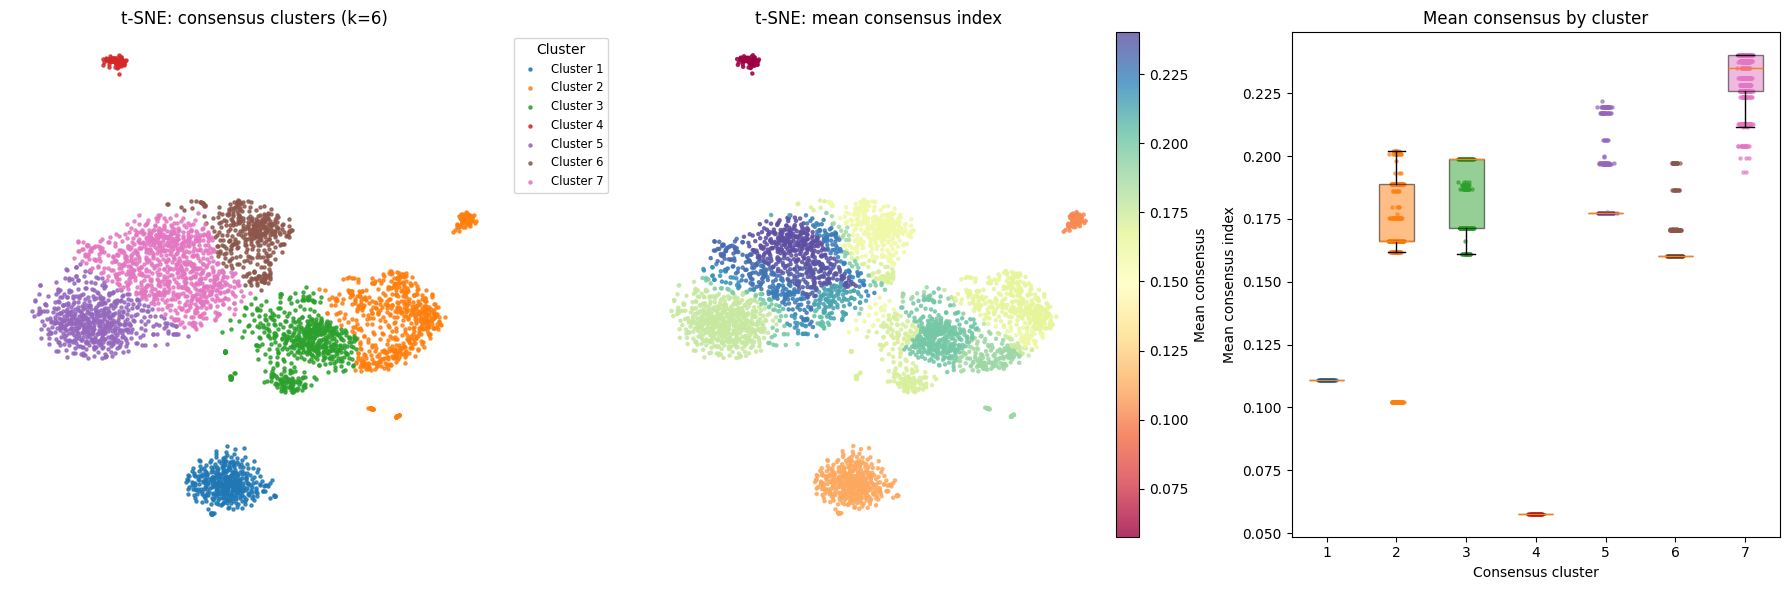

In [ ]:
mean_consensus = consensus_mat.mean(axis=1)
vmin, vmax     = np.percentile(mean_consensus, [1, 99])

unique_clusters = np.unique(consensus_labels)
cluster_colors  = {cl: f'C{i}' for i, cl in enumerate(unique_clusters)}

df = pd.DataFrame({
    'cluster':        consensus_labels,
    'mean_consensus': mean_consensus
})

# 2) Plot 1×3 panel with legend on first
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# Panel 1: t-SNE colored by consensus clusters
ax = axes[0]
for cl in unique_clusters:
    mask = (consensus_labels == cl)
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        color=cluster_colors[cl],
        s=5,
        alpha=0.8,
        label=f'Cluster {cl}'
    )
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
ax.set_axis_off()
ax.set_title('t-SNE: consensus clusters (k=7)')

# Panel 2: t-SNE colored by mean consensus index
ax = axes[1]
sc = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=mean_consensus,
    cmap='Spectral',
    vmin=vmin,
    vmax=vmax,
    s=5,
    alpha=0.8
)
ax.set_axis_off()
ax.set_title('t-SNE: mean consensus index')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('Mean consensus')

# Panel 3: Boxplots of mean consensus per cluster with points
ax = axes[2]
data_per_cluster = [df.loc[df['cluster'] == cl, 'mean_consensus'].values 
                    for cl in unique_clusters]
bp = ax.boxplot(
    data_per_cluster,
    positions=np.arange(len(unique_clusters)),
    patch_artist=True,
    showfliers=False
)
for patch, cl in zip(bp['boxes'], unique_clusters):
    patch.set_facecolor(cluster_colors[cl])
    patch.set_alpha(0.5)
for i, cl in enumerate(unique_clusters):
    y = data_per_cluster[i]
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, color=cluster_colors[cl], s=5, alpha=0.6)
ax.set_xticks(np.arange(len(unique_clusters)))
ax.set_xticklabels([str(cl) for cl in unique_clusters])
ax.set_xlabel('Consensus cluster')
ax.set_ylabel('Mean consensus index')
ax.set_title('Mean consensus by cluster')

plt.show()